# 04 · Clustering and comparison


## 0. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram

RANDOM_STATE = 42
DATA_DIR = "../data"

# Final settings from notebook 03
K = 5
GMM_REG_COVAR = 0.01
DBSCAN_EPS = 0.6
DBSCAN_MIN_SAMPLES = 8

## 1. Load data

In [5]:
X = pd.read_csv(f"{DATA_DIR}/X_pca.csv")
sample_idx = pd.read_csv(f"{DATA_DIR}/sample_idx.csv")["row"].values
X_sample = X.iloc[sample_idx]

print("Full data:", X.shape)
print("Sample:   ", X_sample.shape)

Full data: (12330, 4)
Sample:    (3000, 4)


## 2. K-Means (full data)

In [7]:
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X)

pd.Series(kmeans_labels).value_counts().sort_index()

C:\Users\Raina Samanta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Raina Samanta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Raina Samanta\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Raina Samanta\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Raina Samanta\anaconda3\Lib\subprocess.py", line 1538, in _execute_child


0    3534
1     797
2    5029
3     918
4    2052
Name: count, dtype: int64

## 3. Gaussian Mixture Model (full data)

In [10]:
gmm = GaussianMixture(n_components=K, n_init=3, reg_covar=GMM_REG_COVAR, random_state=RANDOM_STATE)
gmm.fit(X)

gmm_labels = gmm.predict(X)            # the most likely component for each session
gmm_probs = gmm.predict_proba(X)       # probability of each component (each row adds up to 1)
gmm_max_prob = gmm_probs.max(axis=1)   # how sure the model is about its top choice

pd.Series(gmm_labels).value_counts().sort_index()

0    2394
1    4284
2     676
3     353
4    4623
Name: count, dtype: int64

In [11]:
# Sessions where the model is unsure (top probability below 0.6)
uncertain = gmm_max_prob < 0.6
print("Sessions with max probability < 0.6:", uncertain.sum())
print("Share of all sessions:              ", round(uncertain.mean(), 4))

Sessions with max probability < 0.6: 57
Share of all sessions:               0.0046


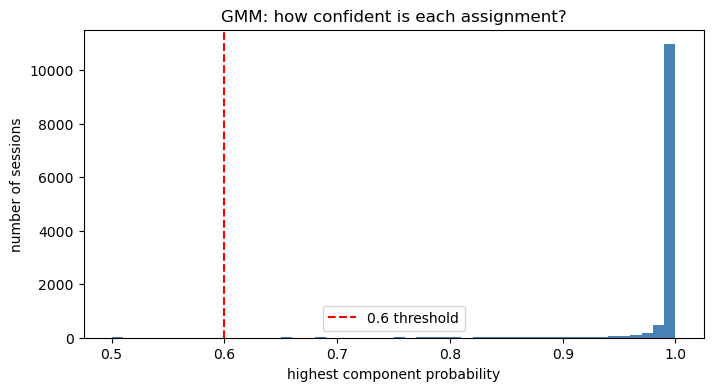

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(gmm_max_prob, bins=50, color="steelblue")
plt.axvline(0.6, color="red", linestyle="--", label="0.6 threshold")
plt.xlabel("highest component probability")
plt.ylabel("number of sessions")
plt.title("GMM: how confident is each assignment?")
plt.legend()
plt.show()

## 4. Agglomerative, Ward linkage (3,000-session sample)

In [14]:
agglo = AgglomerativeClustering(n_clusters=K, linkage="ward")
agglo_labels = agglo.fit_predict(X_sample)

pd.Series(agglo_labels).value_counts().sort_index()

0    1300
1     520
2     267
3     196
4     717
Name: count, dtype: int64

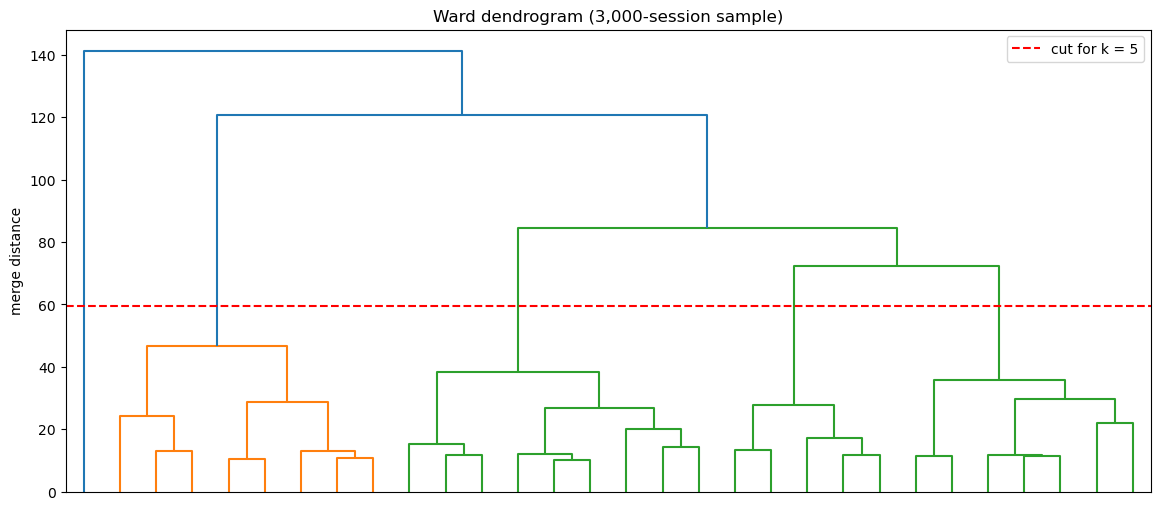

In [15]:
# Dendrogram with the cut that gives 5 clusters
tree = linkage(X_sample, method="ward")

# The merge heights are stored in column 2 of the tree; the last rows are the final (highest) merges.
# To end up with 5 clusters, cut between the 5th-last and 4th-last merge.
cut_height = (tree[-5, 2] + tree[-4, 2]) / 2

plt.figure(figsize=(14, 6))
dendrogram(tree, truncate_mode="lastp", p=30, no_labels=True)
plt.axhline(cut_height, color="red", linestyle="--", label="cut for k = 5")
plt.ylabel("merge distance")
plt.title("Ward dendrogram (3,000-session sample)")
plt.legend()
plt.show()

## 5. DBSCAN (full data)

In [17]:
dbscan = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X)

# Label -1 means noise (not part of any cluster)
pd.Series(dbscan_labels).value_counts().sort_index()

-1     502
 0     676
 1    8904
 2      13
 3    2224
 4      11
Name: count, dtype: int64

In [18]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
noise_share = (dbscan_labels == -1).mean()

print("Clusters found:", n_clusters)
print("Noise sessions:", (dbscan_labels == -1).sum())
print("Noise share:   ", round(noise_share, 4))

Clusters found: 5
Noise sessions: 502
Noise share:    0.0407


## 6. Clusters on PC1 and PC2

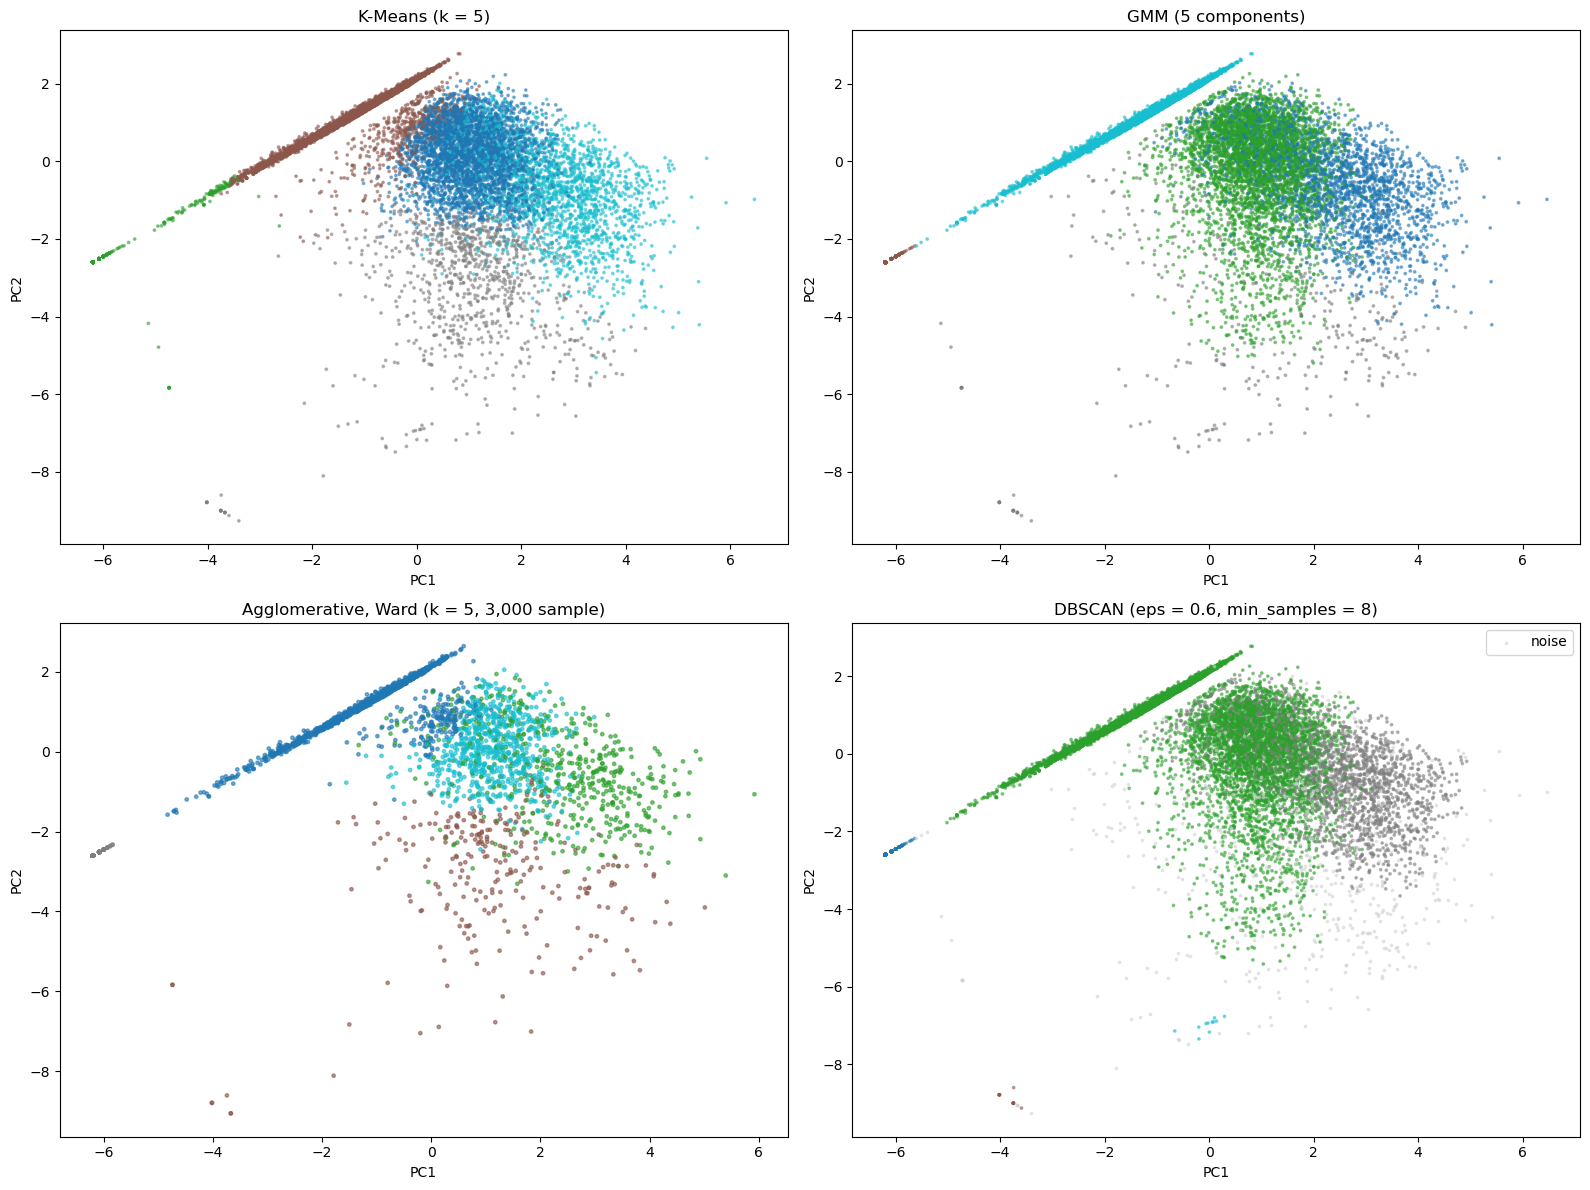

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# K-Means
axes[0, 0].scatter(X["PC1"], X["PC2"], c=kmeans_labels, cmap="tab10", s=3, alpha=0.5)
axes[0, 0].set_title("K-Means (k = 5)")

# GMM
axes[0, 1].scatter(X["PC1"], X["PC2"], c=gmm_labels, cmap="tab10", s=3, alpha=0.5)
axes[0, 1].set_title("GMM (5 components)")

# Agglomerative (sample only)
axes[1, 0].scatter(X_sample["PC1"], X_sample["PC2"], c=agglo_labels, cmap="tab10", s=6, alpha=0.6)
axes[1, 0].set_title("Agglomerative, Ward (k = 5, 3,000 sample)")

# DBSCAN: clusters in colour, noise in grey
is_noise = dbscan_labels == -1
axes[1, 1].scatter(X.loc[~is_noise, "PC1"], X.loc[~is_noise, "PC2"],
                   c=dbscan_labels[~is_noise], cmap="tab10", s=3, alpha=0.5)
axes[1, 1].scatter(X.loc[is_noise, "PC1"], X.loc[is_noise, "PC2"],
                   color="lightgrey", s=3, alpha=0.5, label="noise")
axes[1, 1].set_title(f"DBSCAN (eps = {DBSCAN_EPS}, min_samples = {DBSCAN_MIN_SAMPLES})")
axes[1, 1].legend()

for ax in axes.flatten():
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

## 7. Self-check: cluster sizes add up

In [22]:
print("Rows kept:              ", len(X))
print("K-Means sizes total:    ", np.bincount(kmeans_labels).sum())
print("GMM sizes total:        ", np.bincount(gmm_labels).sum())
print("DBSCAN total (incl. noise):", pd.Series(dbscan_labels).value_counts().sum())
print("Agglomerative total:    ", np.bincount(agglo_labels).sum(), "(sample size 3,000)")

Rows kept:               12330
K-Means sizes total:     12330
GMM sizes total:         12330
DBSCAN total (incl. noise): 12330
Agglomerative total:     3000 (sample size 3,000)


## 8. Agreement between methods: 4 × 4 ARI matrix (same 3,000 sessions)

In [24]:
# For K-Means, GMM and DBSCAN, take their full-data labels for the 3,000 sample rows.
# DBSCAN noise (-1) counts as its own label.
sample_labels = pd.DataFrame({
    "kmeans": kmeans_labels[sample_idx],
    "gmm": gmm_labels[sample_idx],
    "agglo": agglo_labels,
    "dbscan": dbscan_labels[sample_idx],
})

methods = sample_labels.columns
ari_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)

for a in methods:
    for b in methods:
        ari_matrix.loc[a, b] = adjusted_rand_score(sample_labels[a], sample_labels[b])

ari_matrix.round(3)

,kmeans,gmm,agglo,dbscan
kmeans,1.000,0.751,0.757,0.369
gmm,0.751,1.000,0.684,0.488
agglo,0.757,0.684,1.000,0.435
dbscan,0.369,0.488,0.435,1.000


In [26]:
# Cross-tables: how do K-Means clusters map onto the other methods? (full data)
print(pd.crosstab(kmeans_labels, gmm_labels, rownames=["kmeans"], colnames=["gmm"]))
print()
print(pd.crosstab(kmeans_labels, dbscan_labels, rownames=["kmeans"], colnames=["dbscan"]))

gmm        0     1    2    3     4
kmeans                            
0        167  3352    0   15     0
1          0     0  676    9   112
2        189   295    0   34  4511
3         35   637    0  246     0
4       2003     0    0   49     0

dbscan   -1    0     1   2     3   4
kmeans                              
0        38    0  3352   0   144   0
1        12  676   109   0     0   0
2        41    0  4805   0   183   0
3       231    0   638  13    25  11
4       180    0     0   0  1872   0


## 9. Save labels

In [28]:
labels_full = pd.DataFrame({
    "kmeans": kmeans_labels,
    "gmm": gmm_labels,
    "gmm_max_prob": gmm_max_prob,
    "dbscan": dbscan_labels,
})
labels_full.to_csv(f"{DATA_DIR}/labels_full.csv", index=False)

sample_labels.insert(0, "row", sample_idx)
sample_labels.to_csv(f"{DATA_DIR}/labels_sample.csv", index=False)

print("Saved:", labels_full.shape, sample_labels.shape)

Saved: (12330, 4) (3000, 5)
